# Mean-Reversion Strategy — Results

DJ30 universe · Daily data 2014–2026 · CAPM residual signal · Logistic Regression

**Splits:** Train 2014–2019 | Val 2020–2022 | Test 2023–2025

In [ ]:
import shutil
shutil.rmtree("data",   ignore_errors=True)
shutil.rmtree("models", ignore_errors=True)
print("Cache cleared.")

In [2]:
import sys, warnings
sys.path.insert(0, ".")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

DATA_DIR  = Path("data")
MODEL_DIR = Path("models")

TRAIN_END = "2019-12-31"
VAL_END   = "2022-12-31"
TEST_END  = "2025-12-31"
SPLITS = {
    "Train": (None,       TRAIN_END),
    "Val":   (TRAIN_END,  VAL_END),
    "Test":  (VAL_END,    TEST_END),
}
COLORS = {"Train": "#4C72B0", "Val": "#DD8452", "Test": "#55A868"}

## 1. Run Pipeline (skip if cache exists)

In [3]:
from data_download import download_prices, compute_returns
from data_prep    import load_ff_factors, build_features
from model        import train
from portfolio    import build_weights

prices  = download_prices()
returns = compute_returns(prices)
ff      = load_ff_factors()
features, targets, zscores = build_features(returns, ff)
bundle  = train(features, targets)
weights = build_weights(features, zscores, bundle)
print("Pipeline complete.")

Loading cached prices...
Loading cached returns...
Loading cached features/targets...
Loading cached model...
Loading cached weights...
Pipeline complete.


## 2. Model Performance

Model: RandomForest

         AUC  Log-Loss  Accuracy
Split                           
Train 0.5837    0.6877    0.5460
Val   0.5078    0.6937    0.5089


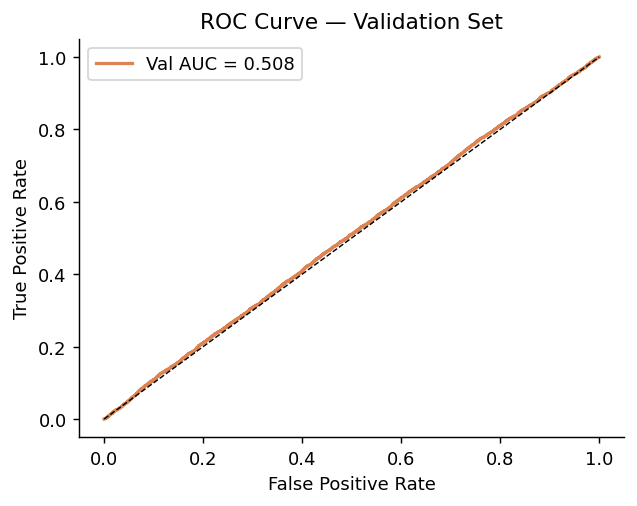

In [4]:
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score, roc_curve
from model import split, predict_proba, FEATURE_COLS

X_train, y_train, X_val, y_val = split(features, targets)

# Evaluate on both train and val
rows = []
for split_name, X, y in [("Train", X_train, y_train), ("Val", X_val, y_val)]:
    prob = predict_proba(bundle, X)
    rows.append({
        "Split":    split_name,
        "AUC":      roc_auc_score(y, prob),
        "Log-Loss": log_loss(y, prob),
        "Accuracy": accuracy_score(y, (prob > 0.5).astype(int)),
    })

print(f"Model: {bundle['name']}\n")
metrics_df = pd.DataFrame(rows).set_index("Split")
print(metrics_df.to_string(float_format="{:.4f}".format))

# ROC curve (validation)
prob_val = predict_proba(bundle, X_val)
fpr, tpr, _ = roc_curve(y_val, prob_val)
auc_val = roc_auc_score(y_val, prob_val)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color=COLORS["Val"], lw=1.8, label=f"Val AUC = {auc_val:.3f}")
ax.plot([0,1],[0,1], "k--", lw=0.8)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Validation Set"); ax.legend()
plt.tight_layout(); plt.show()

## 3. Feature Coefficients (Logistic Regression)

In [ ]:
coefs = bundle["clf"].coef_[0]
feat_names = bundle["feature_cols"]
order = np.argsort(np.abs(coefs))

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#DD8452" if c < 0 else "#4C72B0" for c in coefs[order]]
ax.barh([feat_names[i] for i in order], coefs[order], color=colors)
ax.axvline(0, color="black", lw=0.6)
ax.set_xlabel("Coefficient"); ax.set_title("Logistic Regression Coefficients")
plt.tight_layout(); plt.show()

## 4. Portfolio Statistics

In [6]:
def sharpe(pnl, ann=252):
    return pnl.mean() / pnl.std() * np.sqrt(ann) if pnl.std() > 0 else np.nan

def max_dd(pnl):
    cum = pnl.cumsum()
    return (cum - cum.cummax()).min()

def avg_turnover(w):
    return w.diff().abs().sum(axis=1).mean()

def pct_active(w):
    return (w != 0).sum(axis=1).mean()

# Portfolio daily PnL
fwd_ret = returns.shift(-1)
common  = weights.index.intersection(fwd_ret.index)
pnl     = (weights.loc[common] * fwd_ret.loc[common].reindex(columns=weights.columns, fill_value=0)).sum(axis=1)

rows = []
for name, (start, end) in SPLITS.items():
    mask = pd.Series(True, index=pnl.index)
    if start: mask &= pnl.index > start
    if end:   mask &= pnl.index <= end
    sub = pnl[mask]
    sub_w = weights.loc[weights.index.isin(sub.index)]
    rows.append({
        "Split":         name,
        "Ann. Return":   sub.mean() * 252,
        "Ann. Sharpe":   sharpe(sub),
        "Max Drawdown":  max_dd(sub),
        "Avg Turnover":  avg_turnover(sub_w),
        "Avg Positions": pct_active(sub_w),
    })

stats = pd.DataFrame(rows).set_index("Split")
stats.style.format({
    "Ann. Return":   "{:.2%}",
    "Ann. Sharpe":   "{:.3f}",
    "Max Drawdown":  "{:.2%}",
    "Avg Turnover":  "{:.4f}",
    "Avg Positions": "{:.1f}",
})

,Ann. Return,Ann. Sharpe,Max Drawdown,Avg Turnover,Avg Positions
Split,,,,,
Train,0.00%,nan,0.00%,0.0000,0.0
Val,0.00%,nan,0.00%,0.0000,0.0
Test,0.00%,nan,0.00%,0.0000,0.0


## 5. Equity Curves

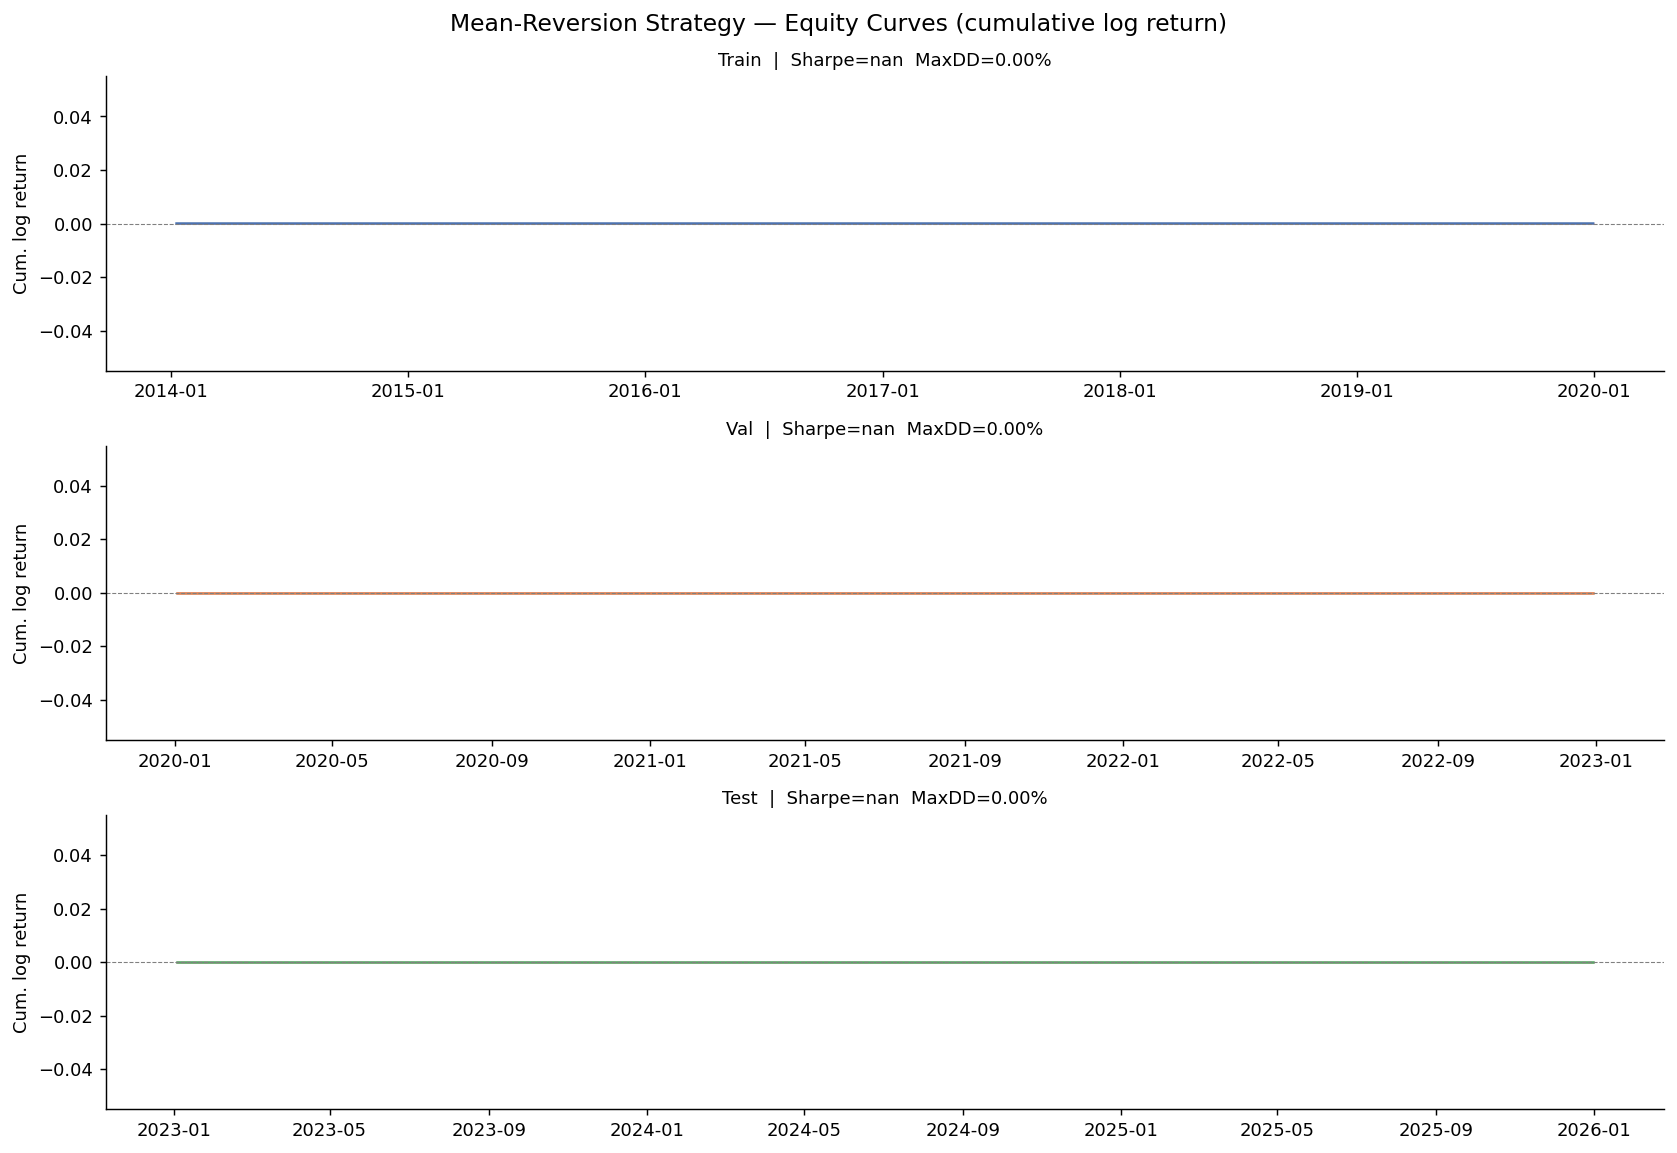

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9))
fig.suptitle("Mean-Reversion Strategy — Equity Curves (cumulative log return)", fontsize=13)

for ax, (name, (start, end)) in zip(axes, SPLITS.items()):
    mask = pd.Series(True, index=pnl.index)
    if start: mask &= pnl.index > start
    if end:   mask &= pnl.index <= end
    sub = pnl[mask]
    cum = sub.cumsum()
    dd  = cum - cum.cummax()

    color = COLORS[name]
    ax.fill_between(dd.index, dd.values, 0, alpha=0.25, color="red")
    ax.plot(cum.index, cum.values, color=color, lw=1.4, label="Cum. return")
    ax.axhline(0, color="grey", lw=0.6, ls="--")
    sr = sharpe(sub)
    ax.set_title(f"{name}  |  Sharpe={sr:.2f}  MaxDD={max_dd(sub):.2%}", fontsize=10)
    ax.set_ylabel("Cum. log return")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.tight_layout()
plt.show()

## 6. Rolling Sharpe (252-day window)

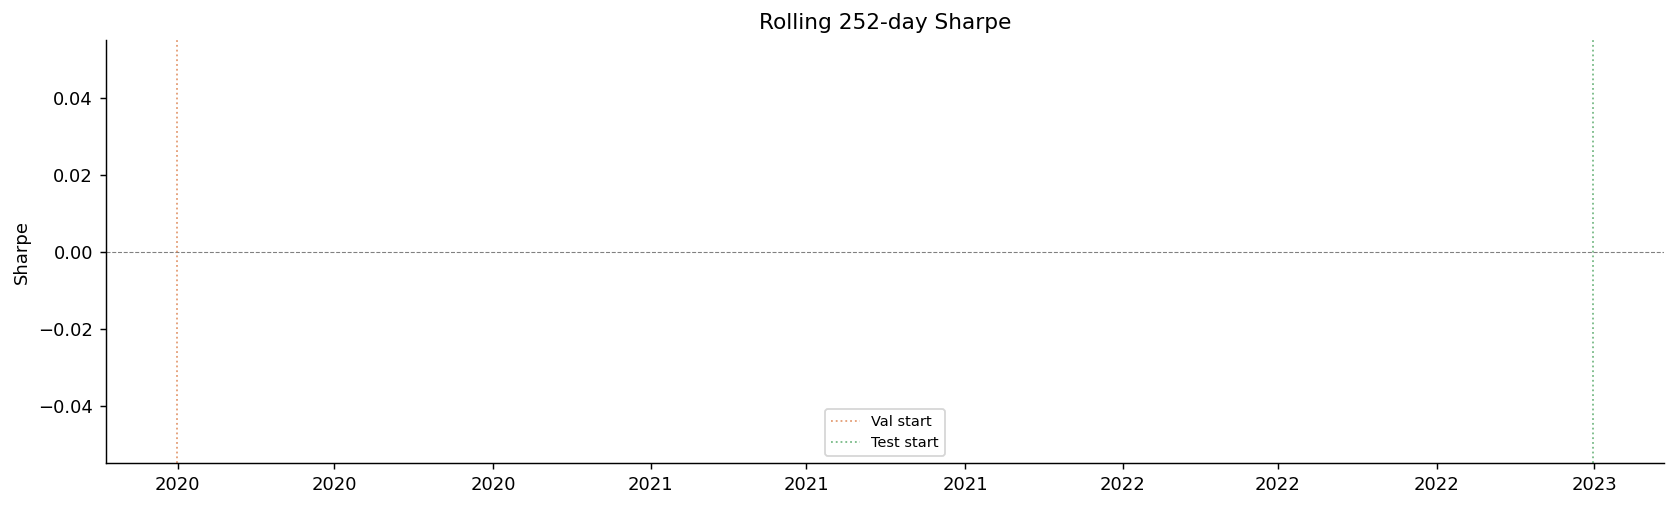

In [8]:
roll_sr = pnl.rolling(252).apply(lambda x: sharpe(pd.Series(x)), raw=False)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(roll_sr.index, roll_sr.values, lw=1.2, color="#4C72B0")
ax.axhline(0, color="grey", lw=0.6, ls="--")
for name, (start, end) in SPLITS.items():
    if start: ax.axvline(pd.Timestamp(start), color=COLORS[name], lw=1, ls=":", alpha=0.8, label=f"{name} start")
ax.set_title("Rolling 252-day Sharpe"); ax.set_ylabel("Sharpe"); ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

## 7. Daily Return Distribution

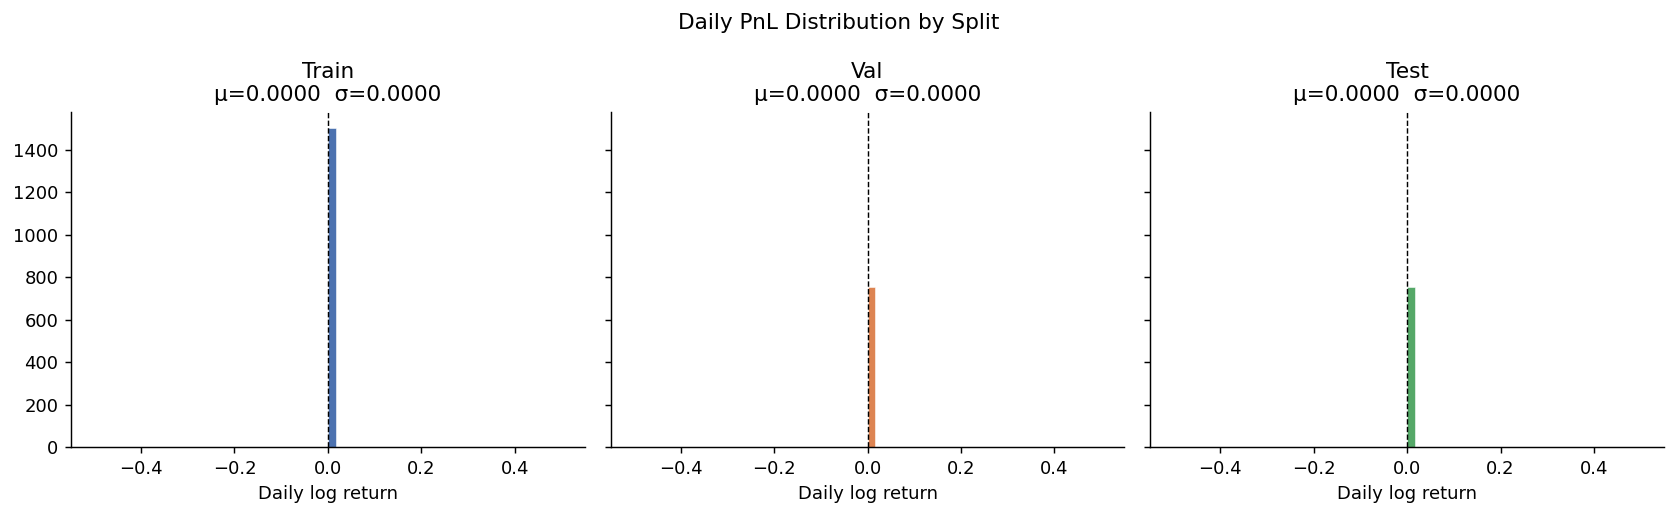

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
fig.suptitle("Daily PnL Distribution by Split", fontsize=12)

for ax, (name, (start, end)) in zip(axes, SPLITS.items()):
    mask = pd.Series(True, index=pnl.index)
    if start: mask &= pnl.index > start
    if end:   mask &= pnl.index <= end
    sub = pnl[mask]
    ax.hist(sub, bins=60, color=COLORS[name], edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="black", lw=0.8, ls="--")
    ax.set_title(f"{name}\nμ={sub.mean():.4f}  σ={sub.std():.4f}")
    ax.set_xlabel("Daily log return")

plt.tight_layout(); plt.show()